In [1]:
from anndata import AnnData
import scanpy as sc
import squidpy as sq
import pandas as pd
import anndata

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Set parameters

In [2]:
neighbors = 15
nPCs = 30
leiden_resolution = 1

In [3]:
adata_CosMx = sc.read_h5ad("/home/levinsj/spatial/adata/project_Files/Fetal/fetal_annotated_AllCells_withXenium.h5ad")
adata_scRNA = sc.read_h5ad("/home/levinsj/Fetal_dir/CellBenderCorrected/04_annotated/MergedFetalOnly_annotated_all_final.h5ad")

/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


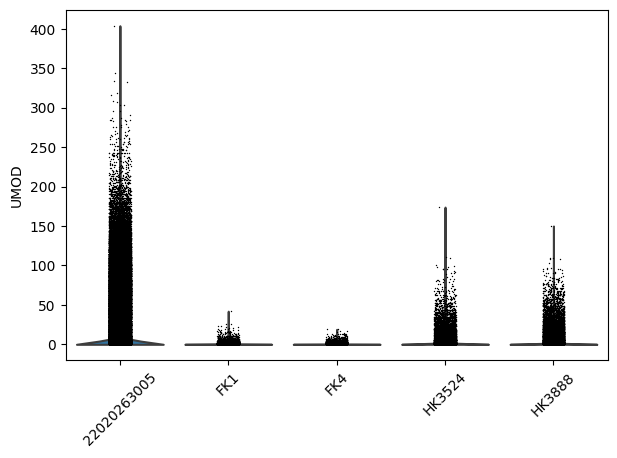

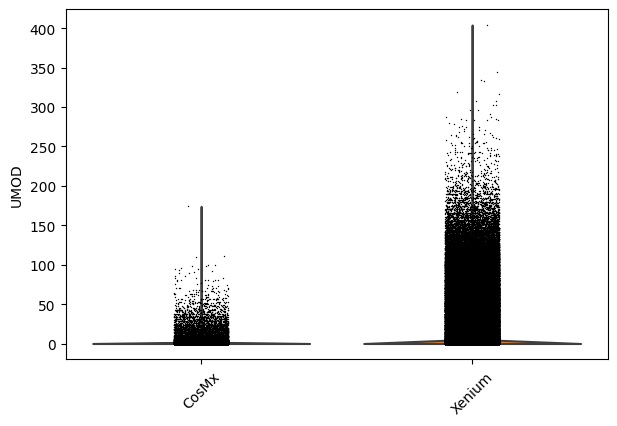

In [4]:
adata_CosMx.obs['Count_percentile'] = adata_CosMx.obs['nCount_RNA'].rank(pct=True) * 100
adata_CosMx.layers["counts"] = adata_CosMx.layers["All_counts"].copy()

sc.pl.violin(adata_CosMx, keys = ['UMOD'],  size = 1, groupby = 'sample', rotation= 45, layer = "counts")
sc.pl.violin(adata_CosMx, keys = ['UMOD'],  size = 1, groupby = 'tech', rotation= 45, layer = "counts")


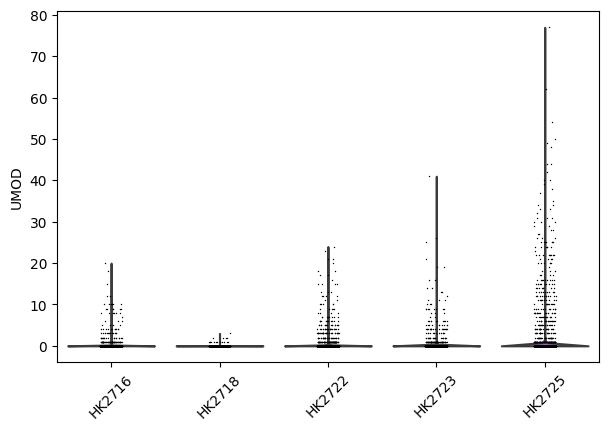

In [5]:
adata_scRNA.obs['Count_percentile'] = adata_scRNA.obs['total_counts'].rank(pct=True) * 100
adata_scRNA.obs["tech"] = "scRNA"

sc.pl.violin(adata_scRNA, keys = ['UMOD'],  size = 1, groupby = 'sample', rotation= 45,use_raw = False, layer = "counts")


In [6]:
adata_merge = anndata.concat([adata_CosMx,adata_scRNA], join = "outer")

adata_merge

/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 955695 × 24432
    obs: 'sample', 'tech', 'type', 'Count_percentile', 'nCount_RNA', 'nFeature_RNA', 'doublet_scores', 'predicted_doublets', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', 'leiden', 'cellType', 'leiden2', 'cellType2', 'cellType3'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'All_counts', 'counts', 'log1p'

In [7]:
adata_merge.layers

Layers with keys: All_counts, counts, log1p

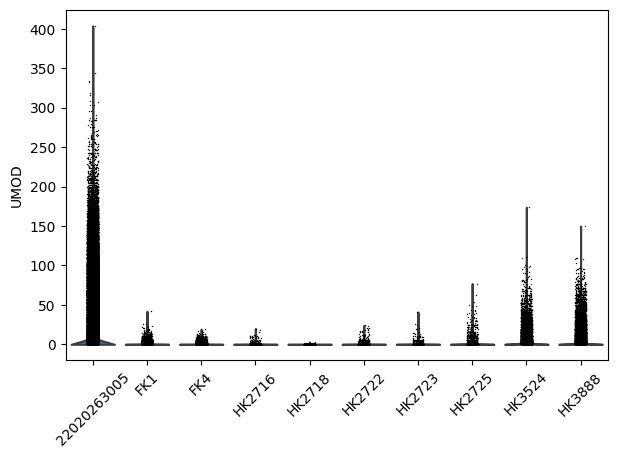

In [8]:
sc.pl.violin(adata_merge, keys = ['UMOD'],  size = 1, groupby = 'sample', rotation= 45, layer = "counts")


In [9]:
adata_merge.X = adata_merge.layers["counts"]

keep_str = ["sample","type",'tech',]
keep_numer = ["pct_counts_mt","total_counts","nCount_RNA", "n_genes_by_counts"]
keep = keep_str + keep_numer
adata_merge.obs= adata_merge.obs[keep]

# ensure proper data types
for i in keep_str:
    adata_merge.obs[i]= adata_merge.obs[i].astype('str')

for i in keep_numer:
    adata_merge.obs[i]= adata_merge.obs[i].astype('float')


In [10]:
adata_merge.raw = adata_merge

adata_merge = adata_merge[:,adata_CosMx.var_names]

systemChecks = adata_merge.var_names.str.startswith('SystemControl')
neg_probes = adata_merge.var_names.str.startswith('Negative')
remove = np.add(neg_probes, systemChecks)
keep = np.invert(remove)

adata_merge = adata_merge[:,keep]

In [11]:
malat1 = adata_merge.var_names.str.startswith('MALAT1')
mito_genes = adata_merge.var_names.str.startswith('MT-')
hb_genes = adata_merge.var_names.str.contains('^HB[^(P)]')

remove = np.add(mito_genes, malat1)
remove = np.add(remove, hb_genes)

keep = np.invert(remove)

adata_merge = adata_merge[:,keep]

In [12]:
print(adata_merge)
adata_merge.write_h5ad(filename = "/home/levinsj/spatial/adata/project_Files/Fetal/fetal_annotated_AllCells_preSCVI_final_xenium.h5ad")


View of AnnData object with n_obs × n_vars = 955695 × 659
    obs: 'sample', 'type', 'tech', 'pct_counts_mt', 'total_counts', 'nCount_RNA', 'n_genes_by_counts'
    uns: 'sample_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'All_counts', 'counts', 'log1p'


/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.8/dist-pac